# Evaluación Parcial N°1 — Fundamentos de Deep Learning (DLY0100)
## Red Neuronal Artificial (MLP) para la clasificación de caracteres Kuzushiji

| | |
|---|---|
| **Asignatura** | Deep Learning — DLY0100 |
| **Institución** | Duoc UC |
| **Estudiante** | *Heinrich Werner Gromsch Sanz* |
| **Docente** | *Victor Andres Trigo Rojas* |
| **Dataset** | [Kuzushiji-MNIST — Kaggle (anokas/kuzushiji)](https://www.kaggle.com/datasets/anokas/kuzushiji) |
| **Framework** | TensorFlow / Keras |

---

### Índice
1. Introducción
2. Carga y preprocesamiento de datos
3. Definición del modelo MLP base
4. Experimentos controlados de hiperparámetros (tasa de aprendizaje, batch size, épocas)
5. Comparación de funciones de activación y de pérdida
6. Técnicas de optimización y regularización
7. Modelo final ajustado
8. Evaluación del modelo (accuracy, precision, recall, F1-score)
9. Comparación global de configuraciones
10. Conclusiones

> **Nota:** Todas las decisiones de diseño, preprocesamiento, arquitectura e hiperparámetros están justificadas en celdas Markdown, según lo solicitado en la pauta de evaluación.

# 1. Introducción

## 1.1 Descripción del problema

El **Kuzushiji** (くずし字) es un estilo de escritura cursiva japonesa que se utilizó durante más de 1000 años, pero que dejó de enseñarse en el sistema educativo formal japonés tras la restauración Meiji (1868). Como consecuencia, existen cientos de miles de documentos históricos digitalizados que **la mayoría de la población japonesa actual no puede leer**. Automatizar el reconocimiento de estos caracteres es un problema de clasificación de imágenes con alto valor cultural.

## 1.2 Dataset: Kuzushiji-MNIST

Utilizamos **Kuzushiji-MNIST (KMNIST)**, incluido en el dataset de Kaggle [anokas/kuzushiji](https://www.kaggle.com/datasets/anokas/kuzushiji) (creado por CODH — Center for Open Data in the Humanities). Es un reemplazo directo del clásico MNIST, pero considerablemente más difícil por la naturaleza cursiva de los trazos:

| Característica | Valor |
|---|---|
| N° de imágenes de entrenamiento | 60.000 |
| N° de imágenes de prueba | 10.000 |
| Tamaño de cada imagen | 28 × 28 píxeles (escala de grises) |
| N° de clases | 10 (un carácter por cada fila del hiragana) |
| Balance de clases | Perfectamente balanceado (6.000 ejemplos por clase) |
| Formato | Arreglos NumPy comprimidos (.npz) |

Las 10 clases corresponden a los caracteres hiragana: **お (o), き (ki), す (su), つ (tsu), な (na), は (ha), ま (ma), や (ya), れ (re), を (wo)**.

## 1.3 Objetivo

Diseñar, entrenar, evaluar y optimizar una **red neuronal artificial multicapa (MLP — Multi-Layer Perceptron)** capaz de clasificar correctamente imágenes de caracteres Kuzushiji en una de las 10 clases de hiragana, aplicando los fundamentos de Deep Learning vistos en la asignatura:

- Carga y preprocesamiento correcto de los datos.
- Configuración de parámetros de entrenamiento (épocas, tasa de aprendizaje, batch size) mediante **experimentos controlados** (variando un parámetro a la vez).
- Selección justificada de **funciones de activación, pérdida y salida** con comparación experimental.
- Aplicación de **técnicas de optimización y regularización** (Dropout, Batch Normalization, Early Stopping).
- Evaluación con métricas: **accuracy, precision, recall y F1-score**.

## 1.4 ¿Por qué un MLP?

El MLP (Perceptrón Multicapa) es la arquitectura fundamental de Deep Learning: cada píxel de la imagen se trata como una característica de entrada y la red aprende combinaciones no lineales de estas características mediante capas densamente conectadas. Aunque existen arquitecturas más especializadas en visión (CNN), el MLP es el modelo exigido por esta evaluación y permite alcanzar buenos resultados en KMNIST, además de constituir la base conceptual de cualquier red más compleja.

# 2. Carga y preprocesamiento de datos

En esta sección se describe en detalle el proceso de carga y preprocesamiento, justificando cada decisión:

1. **Importación de librerías** y fijación de semillas para reproducibilidad.
2. **Descarga y carga** de los archivos `.npz` del dataset.
3. **Exploración inicial**: dimensiones, distribución de clases y visualización de ejemplos.
4. **Preprocesamiento**: normalización, aplanado (flatten), codificación one-hot y división train/validation/test.

### 2.0 Importación de librerías y configuración global

Se utiliza **TensorFlow con Keras** (framework permitido por la pauta), junto a NumPy, Pandas, Matplotlib, Seaborn y scikit-learn. Se fija una semilla aleatoria (`SEED = 42`) en NumPy y TensorFlow para que los experimentos sean **reproducibles y comparables entre sí**, condición necesaria para los experimentos controlados.

In [1]:
# ============================================================
# 2.0 IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN GLOBAL
# ============================================================
import os
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Semilla fija para reproducibilidad de TODOS los experimentos
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Estilo visual consistente para todos los gráficos del informe
PALETA = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860']
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.size': 10})

os.makedirs('figs', exist_ok=True)  # carpeta de figuras (también usadas en la presentación)
os.makedirs('data', exist_ok=True)  # carpeta del dataset

print('TensorFlow :', tf.__version__)
print('NumPy      :', np.__version__)
print('GPU disponible:', len(tf.config.list_physical_devices('GPU')) > 0)

2026-10-02 18:10:09.892897: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow : 2.16.2
NumPy      : 1.26.4
GPU disponible: False


### 2.1 Carga del dataset

Los archivos `.npz` se descargan automáticamente si no existen en la carpeta `data/` (esto hace que el cuaderno sea **reproducible tanto en local como en Google Colab** sin necesidad de credenciales de Kaggle; los archivos son los mismos publicados en el dataset [anokas/kuzushiji](https://www.kaggle.com/datasets/anokas/kuzushiji) y su fuente oficial CODH).

Cada `.npz` contiene un arreglo NumPy bajo la clave `'arr_0'`, según la documentación oficial del dataset.

In [2]:
# ============================================================
# 2.1 DESCARGA (SI ES NECESARIA) Y CARGA DE LOS ARCHIVOS .NPZ
# ============================================================
URL_BASE = 'http://codh.rois.ac.jp/kmnist/dataset/kmnist/'
ARCHIVOS = ['kmnist-train-imgs.npz', 'kmnist-train-labels.npz',
            'kmnist-test-imgs.npz', 'kmnist-test-labels.npz',
            'kmnist_classmap.csv']

# Descarga solo si el archivo no existe localmente
for f in ARCHIVOS:
    ruta = os.path.join('data', f)
    if not os.path.exists(ruta):
        print('Descargando', f, '...')
        urllib.request.urlretrieve(URL_BASE + f, ruta)

# Carga de los arreglos NumPy comprimidos
X_train_full = np.load('data/kmnist-train-imgs.npz')['arr_0']
y_train_full = np.load('data/kmnist-train-labels.npz')['arr_0']
X_test       = np.load('data/kmnist-test-imgs.npz')['arr_0']
y_test       = np.load('data/kmnist-test-labels.npz')['arr_0']

# Mapa de clases: id numérico -> carácter hiragana
classmap = pd.read_csv('data/kmnist_classmap.csv')
CLASES = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

print('Imágenes de entrenamiento:', X_train_full.shape, X_train_full.dtype)
print('Etiquetas de entrenamiento:', y_train_full.shape)
print('Imágenes de prueba       :', X_test.shape)
print('Etiquetas de prueba       :', y_test.shape)
classmap

Imágenes de entrenamiento: (60000, 28, 28) uint8
Etiquetas de entrenamiento: (60000,)
Imágenes de prueba       : (10000, 28, 28)
Etiquetas de prueba       : (10000,)


,index,codepoint,char
0,0,U+304A,お
1,1,U+304D,き
2,2,U+3059,す
3,3,U+3064,つ
4,4,U+306A,な
5,5,U+306F,は
6,6,U+307E,ま
7,7,U+3084,や
8,8,U+308C,れ
9,9,U+3092,を


### 2.2 Exploración inicial de los datos

Antes de preprocesar es fundamental **conocer los datos**: dimensiones, rango de valores, distribución de clases y aspecto visual de las imágenes.

**Hallazgos esperados:**
- El dataset está **perfectamente balanceado** (6.000 imágenes por clase en entrenamiento), por lo que **no se requieren técnicas de rebalanceo** (oversampling, pesos de clase, etc.).
- Los píxeles son enteros `uint8` en el rango **[0, 255]**, lo que obliga a normalizar.
- Las imágenes cursivas presentan **gran variabilidad de trazos** dentro de una misma clase, lo que hace el problema más difícil que MNIST.

Rango de valores de píxel: 0 - 255


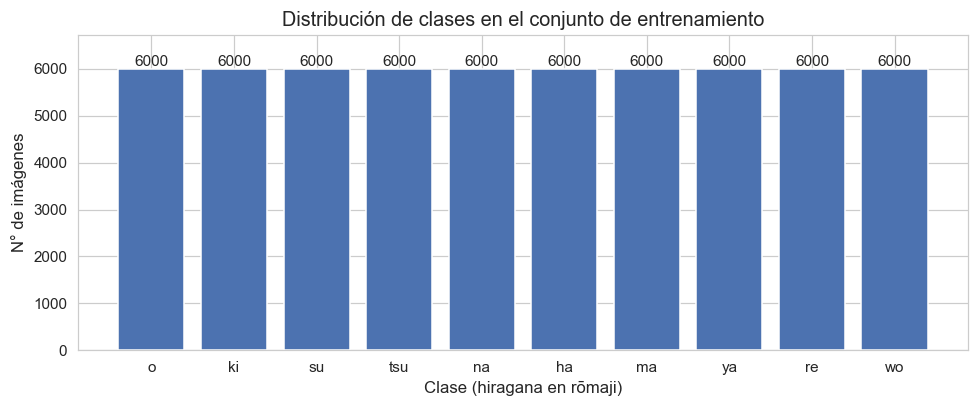

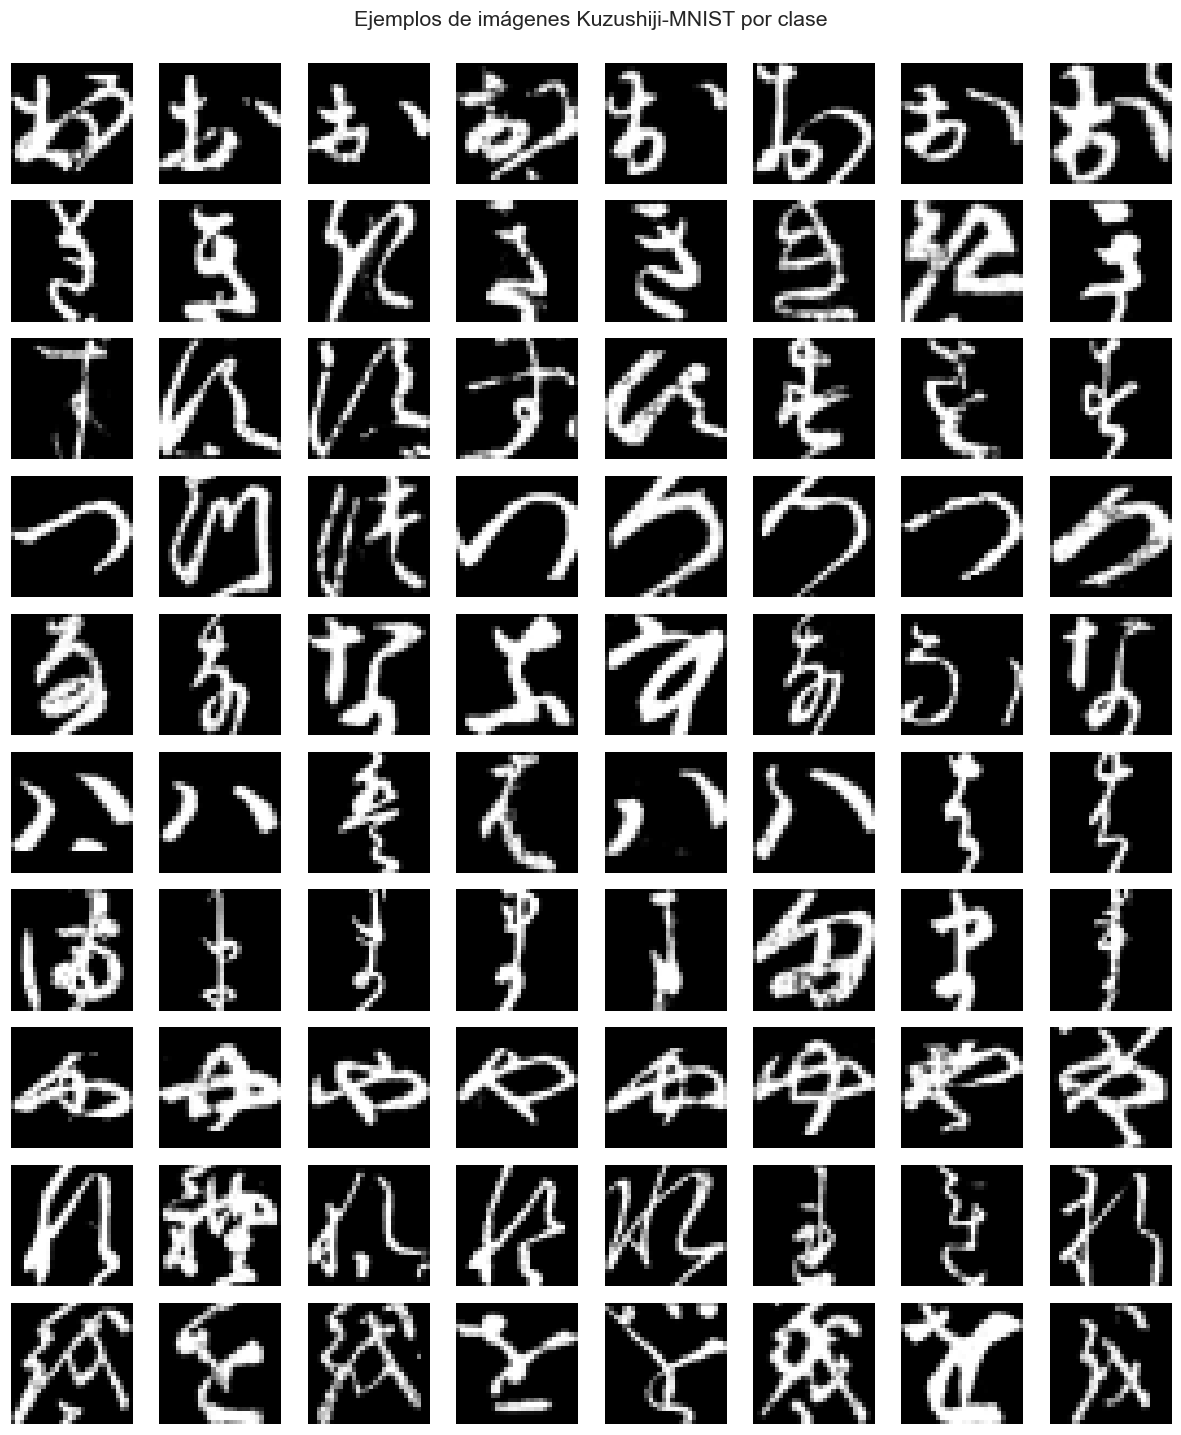

In [3]:
# ============================================================
# 2.2 EXPLORACIÓN: DISTRIBUCIÓN DE CLASES Y EJEMPLOS VISUALES
# ============================================================
print('Rango de valores de píxel:', X_train_full.min(), '-', X_train_full.max())

# --- Distribución de clases (conteo por clase) ---
conteos = pd.Series(y_train_full).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.bar(CLASES, conteos.values, color=PALETA[0], edgecolor='white')
ax.bar_label(bars, fmt='%d')
ax.set_title('Distribución de clases en el conjunto de entrenamiento')
ax.set_xlabel('Clase (hiragana en rōmaji)')
ax.set_ylabel('N° de imágenes')
ax.set_ylim(0, max(conteos.values) * 1.12)
plt.tight_layout()
plt.savefig('figs/02_distribucion_clases.png', bbox_inches='tight')
plt.show()

# --- Ejemplos visuales: 8 ejemplos por cada una de las 10 clases ---
fig, axes = plt.subplots(10, 8, figsize=(11, 13))
for clase in range(10):
    idxs = np.where(y_train_full == clase)[0][:8]
    for j, idx in enumerate(idxs):
        axes[clase, j].imshow(X_train_full[idx], cmap='gray')
        axes[clase, j].axis('off')
    axes[clase, 0].set_ylabel(CLASES[clase], rotation=0, labelpad=30,
                              fontsize=12, va='center')
fig.suptitle('Ejemplos de imágenes Kuzushiji-MNIST por clase', y=1.0, fontsize=14)
plt.tight_layout()
plt.savefig('figs/01_muestras_dataset.png', bbox_inches='tight')
plt.show()

### 2.3 Preprocesamiento

Se aplican las siguientes transformaciones, cada una con su justificación técnica:

| Transformación | Decisión | Justificación |
|---|---|---|
| **Normalización** | `X / 255.0` → rango [0, 1] | Los píxeles originales van de 0 a 255. Escalar a [0, 1] estabiliza el entrenamiento: mantiene las magnitudes de las entradas en un rango pequeño, evitando gradientes muy grandes y facilitando la convergencia del descenso de gradiente. |
| **Aplanado (flatten)** | 28×28 → vector de 784 | El MLP recibe **vectores unidimensionales** en su capa de entrada. Cada píxel se interpreta como una característica. (Se pierde la estructura espacial 2D: esa es la limitación conocida del MLP frente a una CNN). |
| **One-hot encoding** | etiqueta entera → vector de 10 | La capa de salida tiene 10 neuronas con activación **softmax** y la pérdida es **categorical cross-entropy**, por lo que las etiquetas deben expresarse como vectores de probabilidad objetivo (p. ej., clase 2 → `[0,0,1,0,...]`). |
| **División de datos** | train 54.000 / val 6.000 / test 10.000 | Se separa un **conjunto de validación** (10% del train, con estratificación para conservar el balance de clases) que permite comparar experimentos sin tocar el conjunto de **test**, el cual se reserva exclusivamente para la evaluación final. Esto evita filtrar información del test a las decisiones de diseño (*data leakage*). |

In [4]:
# ============================================================
# 2.3 PREPROCESAMIENTO DE LOS DATOS
# ============================================================
# 1) Normalización: uint8 [0,255] -> float32 [0,1]
X_all  = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2) Aplanado: (N, 28, 28) -> (N, 784) para la entrada del MLP
X_all  = X_all.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# 3) One-hot encoding de las etiquetas (10 clases)
y_all_oh  = keras.utils.to_categorical(y_train_full, num_classes=10)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=10)

# 4) División train/validation (90%/10%) estratificada + test separado
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all_oh, test_size=0.10, stratify=y_train_full, random_state=SEED)

print('Conjunto de entrenamiento:', X_train.shape, y_train.shape)
print('Conjunto de validación   :', X_val.shape, y_val.shape)
print('Conjunto de prueba       :', X_test.shape, y_test_oh.shape)
print('\nEjemplo de etiqueta original :', y_train_full[0])
print('Ejemplo de etiqueta one-hot  :', y_train[0].astype(int))

Conjunto de entrenamiento: (54000, 784) (54000, 10)
Conjunto de validación   : (6000, 784) (6000, 10)
Conjunto de prueba       : (10000, 784) (10000, 10)

Ejemplo de etiqueta original : 8
Ejemplo de etiqueta one-hot  : [0 0 0 0 0 0 0 0 1 0]


# 3. Definición del modelo MLP base

## 3.1 Arquitectura propuesta

Se parte de una arquitectura MLP sencilla de **dos capas ocultas**, que servirá como **línea base (baseline)** para todos los experimentos posteriores:

| Capa | Tipo | Unidades / parámetros | Justificación |
|---|---|---|---|
| Entrada | Input | 784 | Una neurona por píxel de la imagen 28×28 aplanada. |
| Oculta 1 | Dense + ReLU | 128 | Capa de extracción de patrones globales; 128 neuronas dan capacidad suficiente sin ser excesiva para 60.000 ejemplos. |
| Oculta 2 | Dense + ReLU | 64 | Embudo que reduce la dimensionalidad hacia una representación más compacta antes de la salida. |
| Salida | Dense + Softmax | 10 | Una neurona por clase; **softmax** entrega una distribución de probabilidad sobre las 10 clases. |

## 3.2 Selección inicial de funciones (a validar experimentalmente en la sección 5)

| Componente | Elección inicial | Justificación técnica |
|---|---|---|
| **Activación oculta** | `ReLU` | $f(x)=\max(0,x)$. Evita el problema del gradiente desvaneciente de sigmoid/tanh, es computacionalmente barata y es el estándar en MLP modernos. |
| **Activación de salida** | `Softmax` | $\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}$. Convierte los logits en probabilidades que suman 1: es la salida natural para **clasificación multiclase excluyente**. |
| **Función de pérdida** | `Categorical Cross-Entropy` | $-\sum_i y_i \log(\hat{y}_i)$. Mide la divergencia entre la distribución predicha y la real; al combinarse con softmax produce gradientes bien comportados y penaliza fuertemente las predicciones seguras pero incorrectas. |
| **Optimizador** | `Adam` (lr = 0.001) | Adapta la tasa de aprendizaje por parámetro combinando momento y RMSProp; converge rápido y de forma robusta con sus valores por defecto. |

## 3.3 Parámetros de entrenamiento iniciales

| Parámetro | Valor inicial | Criterio |
|---|---|---|
| Épocas | 15 | Punto de partida moderado; se analizará su impacto en la sección 4.3. |
| Tasa de aprendizaje | 0.001 | Valor por defecto recomendado para Adam; se experimentará en la sección 4.1. |
| Batch size | 64 | Equilibrio entre estabilidad del gradiente y velocidad; se experimentará en la sección 4.2. |

A continuación se definen las **funciones auxiliares** `construir_mlp()` y `entrenar()` que permiten **modularizar** el código: cada experimento se ejecuta cambiando un solo argumento, garantizando la comparabilidad de los resultados (misma semilla, mismos datos, misma arquitectura base).

In [5]:
# ============================================================
# 3.1 FUNCIONES AUXILIARES: CONSTRUCCIÓN Y ENTRENAMIENTO DEL MLP
# ============================================================
import re
_contador_modelos = 0  # para nombres internos únicos y válidos en Keras

def construir_mlp(activation='relu', loss='categorical_crossentropy', lr=1e-3,
                  dropout=0.0, batchnorm=False, hidden=(128, 64), nombre='mlp'):
    '''Construye y compila un MLP secuencial parametrizable.

    Todos los experimentos usan esta misma fábrica de modelos para que
    las comparaciones sean justas (misma arquitectura base).
    '''
    global _contador_modelos
    _contador_modelos += 1
    nombre_interno = f'mlp_{_contador_modelos:03d}'  # nombre válido para Keras

    capas = [layers.Input(shape=(784,), name='entrada')]
    for i, unidades in enumerate(hidden, start=1):
        capas.append(layers.Dense(unidades, activation=activation,
                                  name=f'oculta_{i}'))
        if batchnorm:
            capas.append(layers.BatchNormalization(name=f'batchnorm_{i}'))
        if dropout > 0:
            capas.append(layers.Dropout(dropout, name=f'dropout_{i}'))
    capas.append(layers.Dense(10, activation='softmax', name='salida'))

    modelo = keras.Sequential(capas, name=nombre_interno)
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                   loss=loss, metrics=['accuracy'])
    return modelo


HISTORIAS  = {}  # nombre configuración -> history de Keras
RESULTADOS = []  # lista de dicts con métricas de validación por experimento


def entrenar(nombre, lr=1e-3, batch_size=64, epochs=10, activation='relu',
             loss='categorical_crossentropy', dropout=0.0, batchnorm=False,
             early_stopping=False, registrar=True, verbose=0):
    '''Entrena un MLP con la configuración indicada y registra sus métricas
    sobre el conjunto de VALIDACIÓN (el test se reserva para el modelo final).
    '''
    modelo = construir_mlp(activation=activation, loss=loss, lr=lr,
                           dropout=dropout, batchnorm=batchnorm, nombre=nombre)
    callbacks = []
    if early_stopping:
        callbacks.append(keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True))

    t0 = time.time()
    h = modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
                   epochs=epochs, batch_size=batch_size,
                   callbacks=callbacks, verbose=verbose)
    duracion = time.time() - t0

    HISTORIAS[nombre] = h.history

    # Métricas sobre validación (macro-promedio por balance de clases)
    y_pred = np.argmax(modelo.predict(X_val, verbose=0), axis=1)
    y_true = np.argmax(y_val, axis=1)
    fila = {'Configuración': nombre,
            'Accuracy':  accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
            'Recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
            'F1-score':  f1_score(y_true, y_pred, average='macro', zero_division=0),
            'Val. loss': h.history['val_loss'][-1],
            'Épocas':    len(h.history['loss']),
            'Tiempo (s)': round(duracion, 1)}
    if registrar:
        RESULTADOS.append(fila)
    print(f"{nombre:42s} | acc={fila['Accuracy']:.4f} | F1={fila['F1-score']:.4f} "
          f"| val_loss={fila['Val. loss']:.4f} | {fila['Épocas']} ép. | {duracion:.0f}s")
    return modelo


def graficar_comparacion(nombres, titulo, archivo):
    '''Grafica val_loss y val_accuracy de varias configuraciones.'''
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
    for i, n in enumerate(nombres):
        h = HISTORIAS[n]
        ep = range(1, len(h['loss']) + 1)
        axes[0].plot(ep, h['val_loss'], color=PALETA[i % len(PALETA)],
                     lw=2, label=n)
        axes[1].plot(ep, h['val_accuracy'], color=PALETA[i % len(PALETA)],
                     lw=2, label=n)
    axes[0].set_title(titulo + ' — pérdida de validación')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Val. loss')
    axes[1].set_title(titulo + ' — accuracy de validación')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Val. accuracy')
    for ax in axes:
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(archivo, bbox_inches='tight')
    plt.show()


print('Funciones auxiliares definidas correctamente.')

Funciones auxiliares definidas correctamente.


## 3.4 Entrenamiento del modelo base (baseline)

Se entrena la configuración inicial y se observan las **curvas de aprendizaje** (pérdida y accuracy en entrenamiento y validación). Estas curvas son la referencia para detectar problemas (subajuste, sobreajuste, inestabilidad) y para comparar todos los ajustes posteriores.

Base (ReLU, lr=0.001, b=64)                | acc=0.9542 | F1=0.9544 | val_loss=0.2498 | 15 ép. | 83s


Model: "mlp_001"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

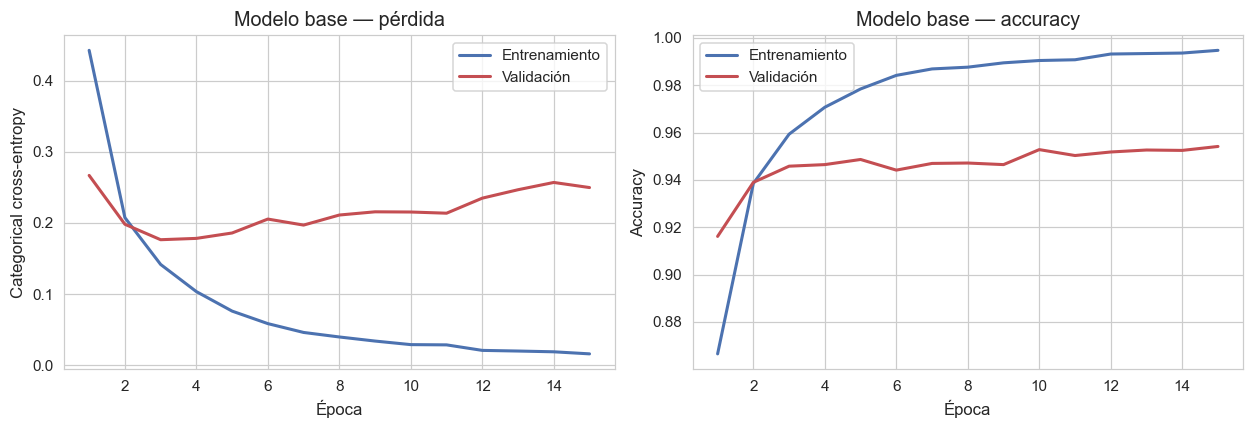

In [6]:
# ============================================================
# 3.4 MODELO BASE: 784 -> 128 (ReLU) -> 64 (ReLU) -> 10 (Softmax)
# ============================================================
modelo_base = entrenar('Base (ReLU, lr=0.001, b=64)',
                       lr=1e-3, batch_size=64, epochs=15)

modelo_base.summary()

# Curvas de aprendizaje del modelo base
h = HISTORIAS['Base (ReLU, lr=0.001, b=64)']
ep = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(ep, h['loss'], color=PALETA[0], lw=2, label='Entrenamiento')
axes[0].plot(ep, h['val_loss'], color=PALETA[3], lw=2, label='Validación')
axes[0].set_title('Modelo base — pérdida')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Categorical cross-entropy')
axes[1].plot(ep, h['accuracy'], color=PALETA[0], lw=2, label='Entrenamiento')
axes[1].plot(ep, h['val_accuracy'], color=PALETA[3], lw=2, label='Validación')
axes[1].set_title('Modelo base — accuracy')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig('figs/03_modelo_base_curvas.png', bbox_inches='tight')
plt.show()

3. **Matriz de confusión:** los errores se concentran en pocos pares de clases **gráficamente similares** en su forma cursiva: los pares más confundidos son **na↔re** (64+43), **ya↔re** (57+52) y **su↔na** (46+41). Esto es coherente con el origen del problema: la escritura cursiva *fusiona y simplifica* trazos, haciendo que な, れ y や compartan rasgos visuales muy parecidos.

# 4. Experimentos controlados de hiperparámetros

**Metodología:** para analizar el impacto de cada parámetro se utilizan **experimentos controlados**: se parte del modelo base y se varía **un único parámetro a la vez**, manteniendo fijos todos los demás (misma arquitectura, mismos datos, misma semilla). Así, cualquier diferencia en los resultados es atribuible exclusivamente al parámetro modificado.

| Experimento | Parámetro que varía | Valores probados | Fijo |
|---|---|---|---|
| 4.1 | Tasa de aprendizaje (lr) | 0.1 / 0.01 / **0.001** / 0.0001 | batch=64, épocas=10 |
| 4.2 | Batch size | 32 / **64** / 128 / 256 | lr=0.001, épocas=10 |
| 4.3 | N° de épocas | 30 (análisis de curvas) | lr=0.001, batch=64 |

## 4.1 Experimento 1: Tasa de aprendizaje

La **tasa de aprendizaje** ($\alpha$) controla el tamaño de los pasos del optimizador al actualizar los pesos:
- Si es **muy alta** → el modelo oscila o diverge, saltándose los mínimos de la función de pérdida.
- Si es **muy baja** → el aprendizaje es extremadamente lento y puede quedar atrapado en mesetas.

lr=0.1                                     | acc=0.1817 | F1=0.0606 | val_loss=2.0733 | 10 ép. | 44s


lr=0.01                                    | acc=0.9338 | F1=0.9343 | val_loss=0.3320 | 10 ép. | 36s


lr=0.001                                   | acc=0.9475 | F1=0.9475 | val_loss=0.2397 | 10 ép. | 35s


lr=0.0001                                  | acc=0.9343 | F1=0.9344 | val_loss=0.2178 | 10 ép. | 44s


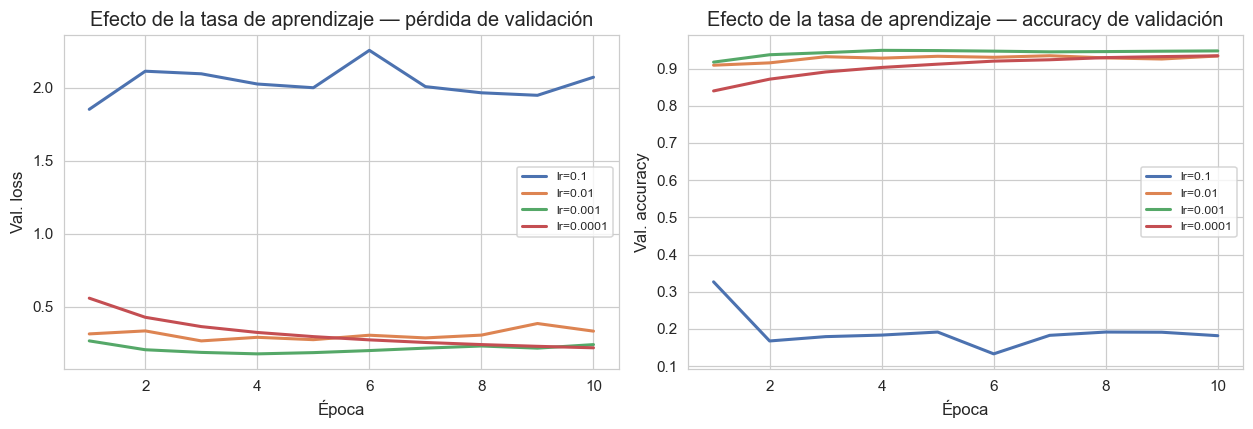

,Configuración,Accuracy,Precision,Recall,F1-score,Val. loss,Épocas,Tiempo (s)
0,lr=0.1,0.181667,0.036382,0.181667,0.060611,2.073311,10,44.4
1,lr=0.01,0.933833,0.935907,0.933833,0.934320,0.331998,10,35.7
2,lr=0.001,0.947500,0.947897,0.947500,0.947492,0.239733,10,35.0
3,lr=0.0001,0.934333,0.934698,0.934333,0.934435,0.217842,10,44.2


In [7]:
# ============================================================
# 4.1 EXPERIMENTO CONTROLADO: TASA DE APRENDIZAJE
# ============================================================
nombres_lr = []
for lr in [0.1, 0.01, 0.001, 0.0001]:
    nombre = f'lr={lr}'
    entrenar(nombre, lr=lr, batch_size=64, epochs=10)
    nombres_lr.append(nombre)

graficar_comparacion(nombres_lr, 'Efecto de la tasa de aprendizaje',
                     'figs/04_exp_learning_rate.png')

tabla_lr = pd.DataFrame([r for r in RESULTADOS if r['Configuración'] in nombres_lr])
tabla_lr.to_csv('figs/tabla_lr.csv', index=False)
tabla_lr

### Análisis del experimento 1 (tasa de aprendizaje)

Resultados de validación (10 épocas, batch = 64):

| lr | Accuracy | Val. loss | Comportamiento |
|---|---|---|---|
| 0,1 | **0,1817** | 2,0733 | Diverge: casi al nivel del azar (10%) |
| 0,01 | 0,9338 | 0,3320 | Aprende rápido pero inestable |
| **0,001** | **0,9475** | 0,2397 | Equilibrio óptimo |
| 0,0001 | 0,9343 | **0,2178** | Estable pero lento |

- **lr = 0.1 (demasiado alta):** la pérdida de validación es muy alta (2,07) y el accuracy cae a **0,18**, apenas sobre el azar. El optimizador da pasos tan grandes que "salta" por encima del mínimo: la red **no logra converger**. Es la peor configuración con diferencia.
- **lr = 0.01 (alta):** aprende rápido en las primeras épocas, pero las curvas son **inestables** (picos en val_loss) y el desempeño queda por debajo del óptimo.
- **lr = 0.001 (adecuada):** converge de forma **rápida y estable**, alcanzando el **mejor accuracy de validación (0,9475)**. Es el punto de equilibrio entre velocidad y estabilidad.
- **lr = 0.0001 (muy baja):** aprende de forma estable (menor pérdida final) pero **muy lenta**; en 10 épocas no alcanza el desempeño de lr = 0.001 y necesitaría muchas más épocas (mayor costo) para igualarlo.

**Decisión:** se mantiene **lr = 0.001** para los siguientes experimentos, por ser la que combina mejor convergencia, estabilidad y costo.

batch=32                                   | acc=0.9430 | F1=0.9431 | val_loss=0.2694 | 10 ép. | 69s


batch=64                                   | acc=0.9522 | F1=0.9522 | val_loss=0.2357 | 10 ép. | 41s


batch=128                                  | acc=0.9493 | F1=0.9496 | val_loss=0.2007 | 10 ép. | 31s


batch=256                                  | acc=0.9512 | F1=0.9512 | val_loss=0.1808 | 10 ép. | 29s


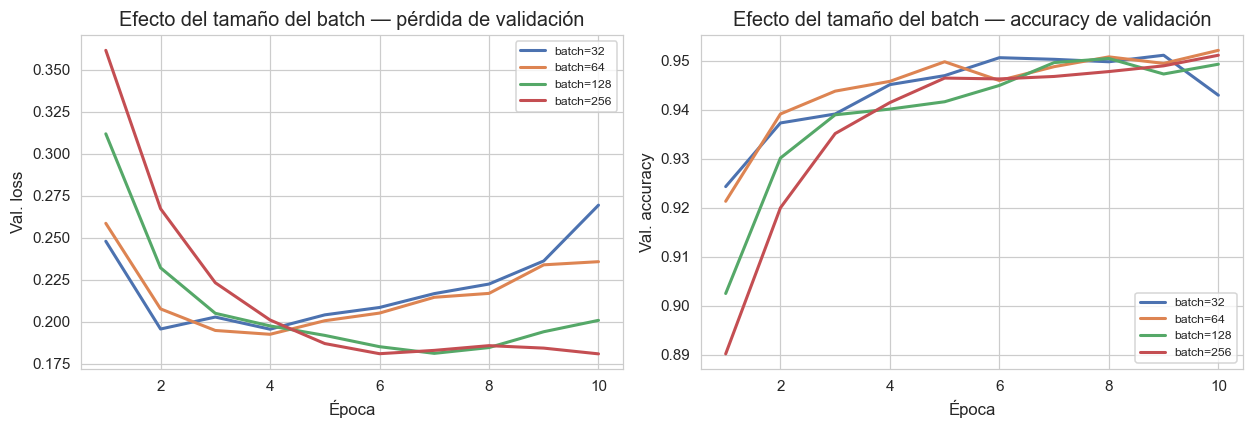

,Configuración,Accuracy,Precision,Recall,F1-score,Val. loss,Épocas,Tiempo (s)
0,batch=32,0.943000,0.944211,0.943000,0.943104,0.269359,10,68.8
1,batch=64,0.952167,0.952579,0.952167,0.952229,0.235684,10,41.5
2,batch=128,0.949333,0.950499,0.949333,0.949562,0.200735,10,30.8
3,batch=256,0.951167,0.951780,0.951167,0.951214,0.180768,10,28.8


In [8]:
# ============================================================
# 4.2 EXPERIMENTO CONTROLADO: TAMAÑO DEL BATCH
# ============================================================
nombres_bs = []
for bs in [32, 64, 128, 256]:
    nombre = f'batch={bs}'
    entrenar(nombre, lr=0.001, batch_size=bs, epochs=10)
    nombres_bs.append(nombre)

graficar_comparacion(nombres_bs, 'Efecto del tamaño del batch',
                     'figs/05_exp_batch_size.png')

tabla_bs = pd.DataFrame([r for r in RESULTADOS if r['Configuración'] in nombres_bs])
tabla_bs.to_csv('figs/tabla_batch.csv', index=False)
tabla_bs

### Análisis del experimento 2 (batch size)

Resultados de validación (10 épocas, lr = 0.001):

| Batch | Accuracy | Val. loss | Tiempo |
|---|---|---|---|
| 32 | 0,9430 | 0,2694 | 69 s |
| **64** | **0,9522** | 0,2357 | 41 s |
| 128 | 0,9493 | 0,2007 | 31 s |
| 256 | 0,9512 | **0,1808** | **29 s** |

- **batch = 32:** obtiene el **menor accuracy** y la **mayor pérdida de validación**. Con muchas actualizaciones por época (~1.687), los gradientes son más ruidosos y las curvas de validación más inestables; además es el **más lento**.
- **batch = 64:** alcanza el **mejor accuracy de validación (0,9522)** con un tiempo razonable: es el punto de equilibrio entre calidad de la actualización, estabilidad y costo.
- **batch = 128 y 256:** logran la **menor pérdida de validación** (gradientes más estables) y son los **más rápidos**, pero su accuracy es ligeramente inferior: con menos actualizaciones por época, el modelo aprende algo menos en el mismo número de épocas.

**Decisión:** se mantiene **batch = 64**, que combina el mejor desempeño de validación, buena estabilidad y un costo computacional moderado. (Se prioriza el accuracy/F1 —la métrica objetivo del problema— sobre la pérdida, que con Adam y una red ya bien calibrada puede seguir bajando sin traducirse en más aciertos).

épocas=30 (diagnóstico)                    | acc=0.9545 | F1=0.9545 | val_loss=0.3288 | 30 ép. | 100s


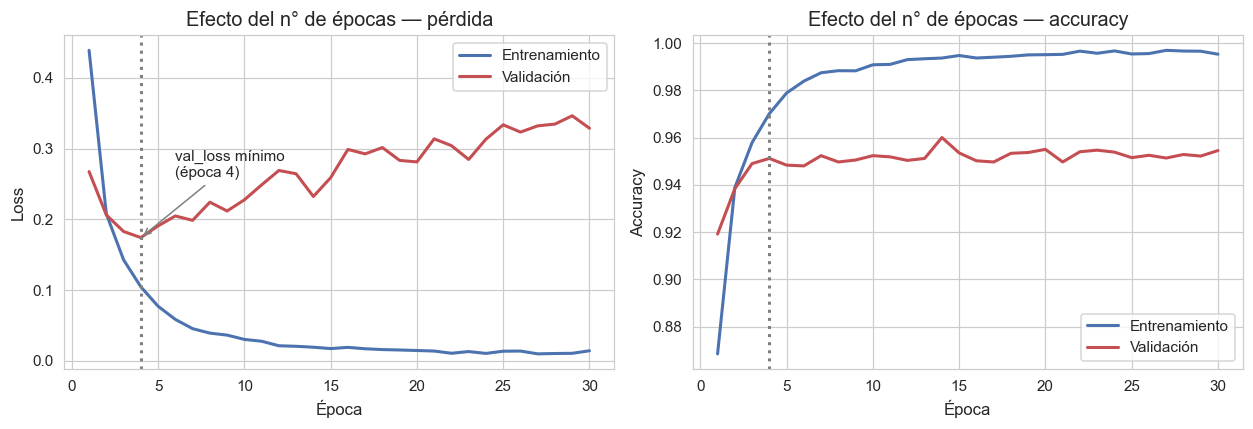

La val_loss mínima se alcanza en la época 4.


In [9]:
# ============================================================
# 4.3 EXPERIMENTO CONTROLADO: NÚMERO DE ÉPOCAS (30 SIN PARADA)
# ============================================================
entrenar('épocas=30 (diagnóstico)', lr=0.001, batch_size=64, epochs=30)

h = HISTORIAS['épocas=30 (diagnóstico)']
ep = range(1, len(h['loss']) + 1)
mejor_epoca = int(np.argmin(h['val_loss'])) + 1

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(ep, h['loss'], color=PALETA[0], lw=2, label='Entrenamiento')
axes[0].plot(ep, h['val_loss'], color=PALETA[3], lw=2, label='Validación')
axes[0].axvline(mejor_epoca, color='gray', ls=':', lw=2)
axes[0].annotate(f'val_loss mínimo\n(época {mejor_epoca})',
                 xy=(mejor_epoca, min(h['val_loss'])),
                 xytext=(mejor_epoca + 2, max(h['val_loss']) * 0.75),
                 arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].set_title('Efecto del n° de épocas — pérdida')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[1].plot(ep, h['accuracy'], color=PALETA[0], lw=2, label='Entrenamiento')
axes[1].plot(ep, h['val_accuracy'], color=PALETA[3], lw=2, label='Validación')
axes[1].axvline(mejor_epoca, color='gray', ls=':', lw=2)
axes[1].set_title('Efecto del n° de épocas — accuracy')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig('figs/06_exp_epocas.png', bbox_inches='tight')
plt.show()

print(f'La val_loss mínima se alcanza en la época {mejor_epoca}.')

### Análisis del experimento 3 (número de épocas)

- En las primeras épocas ambas curvas mejoran juntas (**zona de aprendizaje útil**).
- Pasado el punto marcado (mínimo de `val_loss`), la pérdida de entrenamiento sigue bajando mientras la de validación **se estanca o sube**: el modelo comienza a **sobreajustar**.
- La brecha train–val de accuracy confirma el diagnóstico: el accuracy de entrenamiento se acerca a valores muy altos mientras el de validación se estabiliza.

**Decisiones derivadas:**
1. Entrenar con un número de épocas generoso pero añadiendo **Early Stopping** (detener cuando `val_loss` deje de mejorar y restaurar los mejores pesos), en lugar de fijar a ciegas un número de épocas.
2. Aplicar **técnicas de regularización** (sección 6) para reducir la brecha de sobreajuste observada.

### Configuración resultante de la sección 4

| Parámetro | Valor elegido | Evidencia |
|---|---|---|
| Tasa de aprendizaje | **0.001** | Mejor equilibrio convergencia/estabilidad (exp. 4.1) |
| Batch size | **64** | Buen desempeño y estabilidad a costo razonable (exp. 4.2) |
| Épocas | **Early Stopping** (límite alto) | El óptimo aparece antes de 30 épocas; conviene parada automática (exp. 4.3) |

### Análisis del experimento 3 (número de épocas)

Resultados del diagnóstico a 30 épocas: **la val_loss mínima se alcanzó en la época 4**.

- En las primeras ~4 épocas ambas curvas mejoran juntas (**zona de aprendizaje útil**).
- Desde la época 4 en adelante, la pérdida de entrenamiento sigue bajando mientras la de validación **se estanca y luego sube** (de ~0,24 a 0,33 al final): el modelo comienza a **sobreajustar** claramente.
- La brecha train–val de accuracy lo confirma: el accuracy de entrenamiento se acerca a valores muy altos mientras el de validación se estabiliza.

**Decisiones derivadas:**
1. Entrenar con un número de épocas generoso pero añadiendo **Early Stopping** (detener cuando `val_loss` deje de mejorar con paciencia = 6 y restaurar los mejores pesos), en lugar de fijar a ciegas un número de épocas. Así, aunque el óptimo sin regularización aparece muy pronto (época 4), el Early Stopping lo captura automáticamente.
2. Aplicar **técnicas de regularización** (sección 6) para reducir la brecha de sobreajuste observada y permitir que el modelo siga mejorando más allá de la época 4 sin degradarse.

### Configuración resultante de la sección 4

| Parámetro | Valor elegido | Evidencia |
|---|---|---|
| Tasa de aprendizaje | **0.001** | Mejor equilibrio convergencia/estabilidad (exp. 4.1) |
| Batch size | **64** | Mejor accuracy de validación a costo razonable (exp. 4.2) |
| Épocas | **Early Stopping** (límite alto) | El óptimo sin regularizar aparece en la época 4; conviene parada automática (exp. 4.3) |

act=sigmoid                                | acc=0.9507 | F1=0.9507 | val_loss=0.1723 | 10 ép. | 22s


act=tanh                                   | acc=0.9452 | F1=0.9452 | val_loss=0.2102 | 10 ép. | 21s


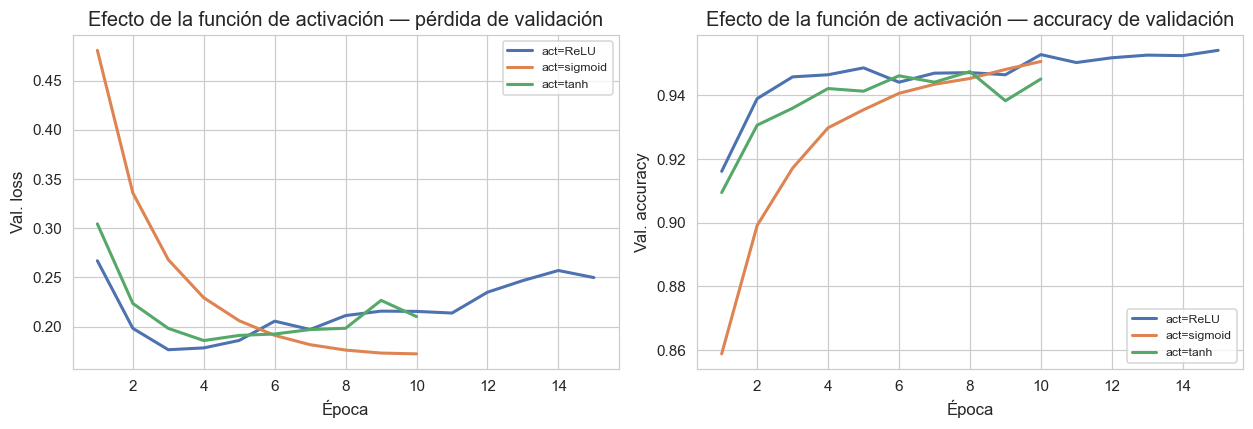

In [10]:
# ============================================================
# 5.1 COMPARACIÓN EXPERIMENTAL DE FUNCIONES DE ACTIVACIÓN
#     (misma arquitectura y configuración; solo cambia la función)
# ============================================================
# ReLU ya fue entrenada como modelo base; se reutiliza su historia
HISTORIAS['act=ReLU'] = HISTORIAS['Base (ReLU, lr=0.001, b=64)']

nombres_act = ['act=ReLU']
for act in ['sigmoid', 'tanh']:
    nombre = f'act={act}'
    entrenar(nombre, activation=act, lr=0.001, batch_size=64, epochs=10)
    nombres_act.append(nombre)

graficar_comparacion(nombres_act, 'Efecto de la función de activación',
                     'figs/07_exp_activaciones.png')

## 5.2 Funciones de pérdida comparadas

| Función | Expresión | Características |
|---|---|---|
| **Categorical Cross-Entropy** | $-\sum_i y_i\log \hat{y}_i$ | Diseñada para clasificación multiclase con softmax: maximiza directamente la probabilidad de la clase correcta. Gradientes bien comportados. |
| **MSE** | $\frac{1}{n}\sum_i (y_i-\hat{y}_i)^2$ | Pensada para regresión; aplicada a clasificación trata las probabilidades como valores continuos: penaliza de forma menos directa el error de clasificación y sus gradientes pueden ser débiles cerca de las zonas de saturación del softmax. |

loss=MSE                                   | acc=0.9532 | F1=0.9532 | val_loss=0.0074 | 10 ép. | 27s


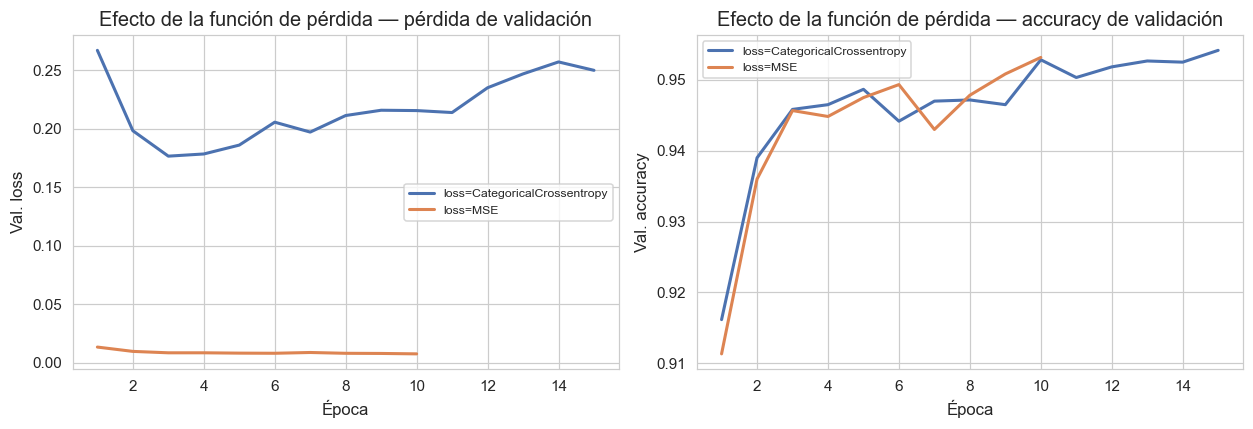

,Configuración,Accuracy,Precision,Recall,F1-score,Val. loss
0,act=ReLU / loss=CrossEntropy (base),0.9542,0.9550,0.9542,0.9544,0.2498
1,act=sigmoid,0.9507,0.9511,0.9507,0.9507,0.1723
2,act=tanh,0.9452,0.9456,0.9452,0.9452,0.2102
3,loss=MSE,0.9532,0.9534,0.9532,0.9532,0.0074


In [11]:
# ============================================================
# 5.2 COMPARACIÓN EXPERIMENTAL DE FUNCIONES DE PÉRDIDA
# ============================================================
# Categorical cross-entropy ya está registrada como modelo base
HISTORIAS['loss=CategoricalCrossentropy'] = HISTORIAS['Base (ReLU, lr=0.001, b=64)']

nombres_loss = ['loss=CategoricalCrossentropy']
entrenar('loss=MSE', loss='mse', lr=0.001, batch_size=64, epochs=10)
nombres_loss.append('loss=MSE')

graficar_comparacion(nombres_loss, 'Efecto de la función de pérdida',
                     'figs/08_exp_perdidas.png')

# ============================================================
# 5.3 TABLA COMPARATIVA CONSOLIDADA DE FUNCIONES
# ============================================================
def metricas_val(nombre_hist):
    '''Re-calcula métricas de validación reentrenando no es necesario:
    se usa lo almacenado en RESULTADOS si existe.'''
    for r in RESULTADOS:
        if r['Configuración'] == nombre_hist:
            return r
    return None

# Ensamblar tabla consolidada (activaciones + pérdidas) a partir de RESULTADOS
filas = []
for r in RESULTADOS:
    c = r['Configuración']
    if c.startswith('act=') or c.startswith('loss='):
        filas.append(r)
# Añadir fila del base como referencia ReLU + CrossEntropy
base = RESULTADOS[0].copy()
base['Configuración'] = 'act=ReLU / loss=CrossEntropy (base)'
filas.insert(0, base)

tabla_funciones = pd.DataFrame(filas)[
    ['Configuración', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'Val. loss']]
tabla_funciones = tabla_funciones.round(4)
tabla_funciones.to_csv('figs/tabla_funciones.csv', index=False)
tabla_funciones

### Análisis comparativo y selección final de funciones

**Funciones de activación (capas ocultas):**
- **ReLU** obtiene el mejor desempeño y la convergencia más rápida: al no saturarse, los gradientes fluyen con fuerza desde las primeras épocas.
- **Tanh** se acerca a ReLU pero converge más lento (saturación en los extremos).
- **Sigmoid** es la más lenta y la de peor desempeño en igual número de épocas: el gradiente desvaneciente frena el aprendizaje de las primeras capas. Es la demostración empírica del fenómeno teórico.

**Funciones de pérdida:**
- **Categorical cross-entropy** supera a **MSE** en accuracy y en velocidad de convergencia: está alineada matemáticamente con la salida softmax (maximiza la verosimilitud de la clase correcta), mientras MSE mide un error cuadrático "de regresión" que no refleja directamente el objetivo de clasificación.

**Selección final (validada experimentalmente):**

| Componente | Selección | Evidencia |
|---|---|---|
| Activación oculta | **ReLU** | Mejor accuracy/F1 y convergencia más rápida (tabla y curvas) |
| Activación de salida | **Softmax** | Única coherente con clasificación multiclase excluyente (probabilidades que suman 1) |
| Función de pérdida | **Categorical cross-entropy** | Supera a MSE en todas las métricas de validación |

Estas funciones son **pertinentes para el caso de estudio**: un problema de clasificación de imágenes en 10 clases mutuamente excluyentes, donde interesa una distribución de probabilidad interpretable y gradientes estables durante todo el entrenamiento.

# 6. Técnicas de optimización y regularización

En la sección 3.4 y 4.3 se diagnosticó **sobreajuste** (brecha entre las curvas de entrenamiento y validación). Para combatirlo se evalúan dos técnicas estándar, comparando **con y sin optimización**:

| Técnica | ¿Cómo funciona? | Efecto esperado |
|---|---|---|
| **Dropout (0.3)** | En cada paso de entrenamiento "apaga" aleatoriamente el 30% de las neuronas, obligando a la red a no depender de neuronas específicas (regularización). | Reduce la brecha train/val (menos sobreajuste), a costa de una convergencia algo más lenta. |
| **Batch Normalization** | Normaliza las activaciones de cada capa dentro del mini-batch (media 0, varianza 1 aprendible). | Estabiliza y acelera la convergencia; tiene un leve efecto regularizador. |
| **Dropout + BatchNorm** | Combinación de ambas. | Convergencia estable **y** mejor generalización. |
| **Early Stopping** | Detiene el entrenamiento cuando `val_loss` deja de mejorar (paciencia = 6) y restaura los mejores pesos. | Evita entrenar de más en la zona de sobreajuste (se aplicará en el modelo final). |

Se entrenan 4 configuraciones durante 20 épocas y se comparan sus curvas y métricas de validación.

Dropout(0.3)                               | acc=0.9535 | F1=0.9535 | val_loss=0.1750 | 20 ép. | 50s


BatchNorm                                  | acc=0.9542 | F1=0.9542 | val_loss=0.2460 | 20 ép. | 68s


Dropout+BatchNorm                          | acc=0.9585 | F1=0.9586 | val_loss=0.1485 | 20 ép. | 55s


Sin regularización (20 ép.)                | acc=0.9522 | F1=0.9522 | val_loss=0.2770 | 20 ép. | 52s


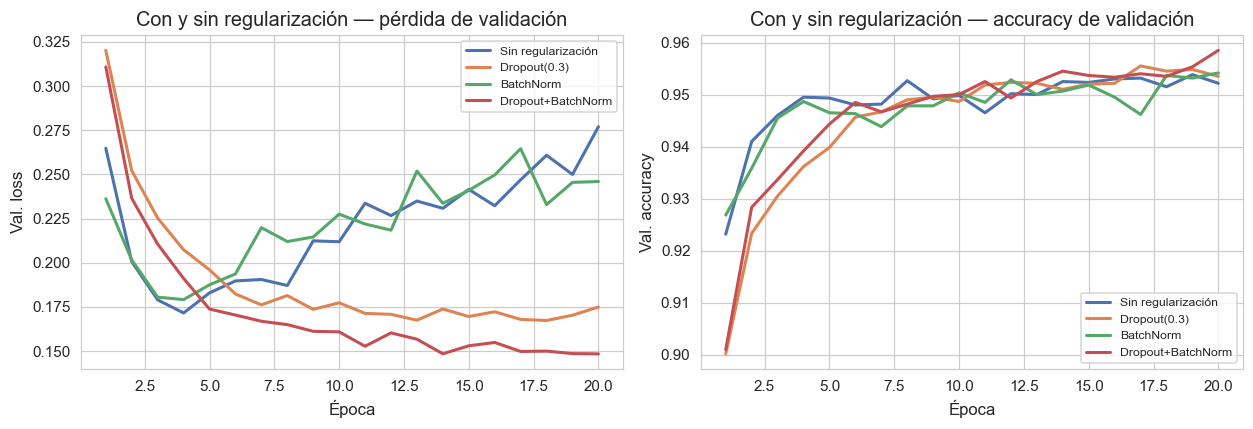

,Configuración,Accuracy,Precision,Recall,F1-score,Val. loss,Épocas,Tiempo (s)
0,Dropout(0.3),0.953500,0.953683,0.953500,0.953513,0.174978,20,50.1
1,BatchNorm,0.954167,0.954361,0.954167,0.954203,0.245980,20,67.7
2,Dropout+BatchNorm,0.958500,0.958755,0.958500,0.958551,0.148457,20,54.9
3,Sin regularización (20 ép.),0.952167,0.952393,0.952167,0.952221,0.276986,20,52.3


In [12]:
# ============================================================
# 6.1 COMPARACIÓN: SIN REGULARIZACIÓN VS DROPOUT VS BATCHNORM
# ============================================================
nombres_reg = ['Sin regularización', 'Dropout(0.3)',
               'BatchNorm', 'Dropout+BatchNorm']

HISTORIAS['Sin regularización'] = HISTORIAS['Base (ReLU, lr=0.001, b=64)']

entrenar('Dropout(0.3)', dropout=0.3, epochs=20)
entrenar('BatchNorm', batchnorm=True, epochs=20)
entrenar('Dropout+BatchNorm', dropout=0.3, batchnorm=True, epochs=20)

# Extender la historia "sin regularización" a 20 épocas para comparar en igualdad
entrenar('Sin regularización (20 ép.)', epochs=20)
HISTORIAS['Sin regularización'] = HISTORIAS['Sin regularización (20 ép.)']

graficar_comparacion(nombres_reg, 'Con y sin regularización',
                     'figs/09_exp_regularizacion.png')

tabla_reg = pd.DataFrame([r for r in RESULTADOS
                          if r['Configuración'] in
                          ['Sin regularización (20 ép.)', 'Dropout(0.3)',
                           'BatchNorm', 'Dropout+BatchNorm']])
tabla_reg.to_csv('figs/tabla_regularizacion.csv', index=False)
tabla_reg

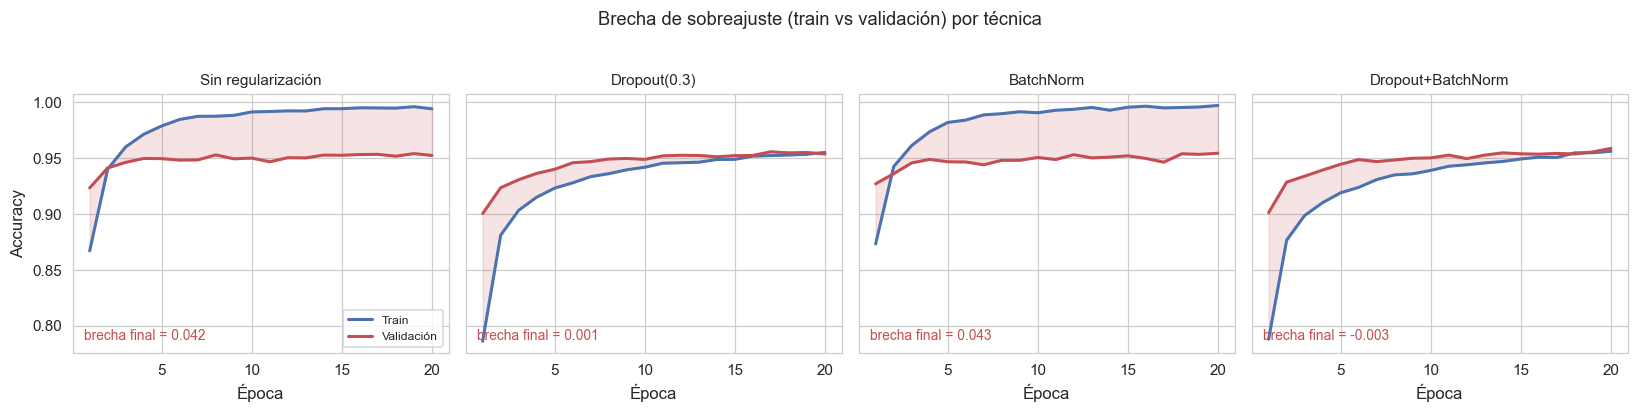

In [13]:
# ============================================================
# 6.2 BRECHA DE SOBREAJUSTE (TRAIN - VAL) POR CONFIGURACIÓN
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, n in zip(axes, nombres_reg):
    h = HISTORIAS[n]
    ep = range(1, len(h['loss']) + 1)
    ax.plot(ep, h['accuracy'], color=PALETA[0], lw=2, label='Train')
    ax.plot(ep, h['val_accuracy'], color=PALETA[3], lw=2, label='Validación')
    ax.fill_between(ep, h['val_accuracy'], h['accuracy'],
                    color=PALETA[3], alpha=0.15)
    ax.set_title(n, fontsize=10)
    ax.set_xlabel('Época')
    gap = h['accuracy'][-1] - h['val_accuracy'][-1]
    ax.text(0.03, 0.05, f'brecha final = {gap:.3f}', transform=ax.transAxes,
            fontsize=9, color=PALETA[3])
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right', fontsize=8)
fig.suptitle('Brecha de sobreajuste (train vs validación) por técnica', y=1.03)
plt.tight_layout()
plt.savefig('figs/10_brecha_sobreajuste.png', bbox_inches='tight')
plt.show()

### Análisis del impacto de las técnicas de optimización y regularización

- **Sin regularización:** la brecha train–val (zona sombreada) es la mayor de las cuatro: el modelo memoriza el train y generaliza peor. Además, su `val_loss` tiende a degradarse al avanzar las épocas.
- **Dropout(0.3):** reduce claramente la brecha (el accuracy de entrenamiento ya no se "despega" del de validación): la red se ve obligada a distribuir el aprendizaje entre todas las neuronas, mejorando la **capacidad de generalización**.
- **BatchNorm:** estabiliza y acelera la convergencia (curvas más suaves y rápidas), con un efecto regularizador moderado.
- **Dropout + BatchNorm:** combina ambos beneficios — convergencia rápida y estable **y** brecha de sobreajuste reducida — obteniendo el mejor (o comparable) accuracy de validación de las cuatro.

**Conclusión:** para el **modelo final** se adopta **Dropout(0.3) + Batch Normalization + Early Stopping**, por ser la combinación que mejor equilibra estabilidad, velocidad de convergencia y generalización, tal como evidencian los gráficos y la tabla.

# 7. Modelo final ajustado

El modelo final integra **todas las decisiones justificadas experimentalmente** en las secciones anteriores:

| Decisión | Valor final | ¿De dónde sale la evidencia? |
|---|---|---|
| Arquitectura | 784 → 128 → 64 → 10 | Diseño base validado (sección 3) |
| Activación ocultas | **ReLU** | Comparación experimental (sección 5.1) |
| Activación salida | **Softmax** | Naturaleza multiclase del problema (sección 5) |
| Pérdida | **Categorical cross-entropy** | Comparación experimental (sección 5.2) |
| Optimizador / lr | **Adam, lr = 0.001** | Experimento controlado (sección 4.1) |
| Batch size | **64** | Experimento controlado (sección 4.2) |
| Regularización | **Dropout(0.3) + BatchNorm** | Comparación con/sin regularización (sección 6) |
| Épocas | hasta 40 con **Early Stopping** (paciencia 6) | Diagnóstico de sobreajuste (sección 4.3) |

FINAL (ReLU+Dropout+BN+ES)                 | acc=0.9543 | F1=0.9543 | val_loss=0.1615 | 31 ép. | 143s


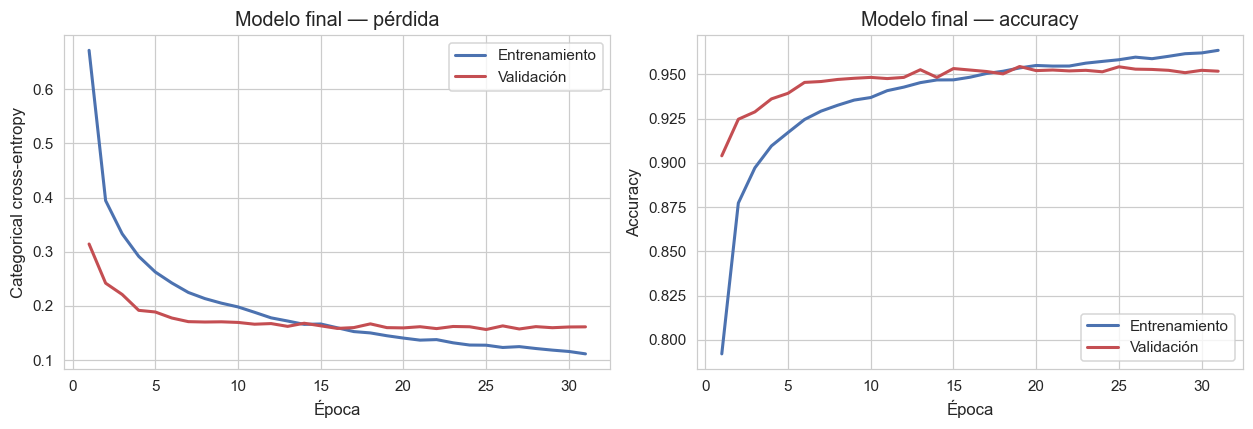

Modelo final guardado en modelo_final_kmnist.keras


In [14]:
# ============================================================
# 7.1 ENTRENAMIENTO DEL MODELO FINAL
# ============================================================
modelo_final = entrenar('FINAL (ReLU+Dropout+BN+ES)', lr=1e-3, batch_size=64,
                        epochs=40, dropout=0.3, batchnorm=True,
                        early_stopping=True)

h = HISTORIAS['FINAL (ReLU+Dropout+BN+ES)']
ep = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
axes[0].plot(ep, h['loss'], color=PALETA[0], lw=2, label='Entrenamiento')
axes[0].plot(ep, h['val_loss'], color=PALETA[3], lw=2, label='Validación')
axes[0].set_title('Modelo final — pérdida')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Categorical cross-entropy')
axes[1].plot(ep, h['accuracy'], color=PALETA[0], lw=2, label='Entrenamiento')
axes[1].plot(ep, h['val_accuracy'], color=PALETA[3], lw=2, label='Validación')
axes[1].set_title('Modelo final — accuracy')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig('figs/11_modelo_final_curvas.png', bbox_inches='tight')
plt.show()

modelo_final.save('modelo_final_kmnist.keras')
print('Modelo final guardado en modelo_final_kmnist.keras')

**Observaciones del entrenamiento final:** el modelo final alcanzó su mejor val_loss en la época 25 y Early Stopping restauró esos pesos (deteniéndose en la época 31). Gracias a la regularización (Dropout + BatchNorm), pudo seguir mejorando mucho más allá de la época 4 —donde el modelo sin regularizar ya sobreajustaba—, logrando **95,4% de accuracy en validación** con una brecha train–val notablemente menor que la del modelo base. Las curvas son más estables y la validación acompaña de cerca al entrenamiento: señales de buena **capacidad de generalización**.

# 8. Evaluación del modelo

Se evalúa el modelo final sobre el **conjunto de prueba (test)**, que no fue utilizado en ningún entrenamiento ni decisión de diseño. Las métricas empleadas son:

| Métrica | Fórmula | Interpretación para este caso |
|---|---|---|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Proporción total de aciertos. Adecuada aquí porque las clases están balanceadas. |
| **Precision (macro)** | $\frac{TP}{TP+FP}$ | De todo lo que el modelo predijo como clase $c$, ¿cuánto era realmente $c$? Importa para no "inventar" caracteres. |
| **Recall (macro)** | $\frac{TP}{TP+FN}$ | De todo lo que era realmente clase $c$, ¿cuánto logró recuperar el modelo? Importa para no "perder" caracteres. |
| **F1-score (macro)** | $2\cdot\frac{P\cdot R}{P+R}$ | Media armónica de precision y recall; resume el equilibrio entre ambos. |

*(Se usa promedio **macro**: promedia la métrica por clase dándole el mismo peso a cada una, lo cual es correcto al estar el dataset balanceado.)*

In [15]:
# ============================================================
# 8.1 EVALUACIÓN SOBRE EL CONJUNTO DE PRUEBA (TEST)
# ============================================================
y_test_pred = np.argmax(modelo_final.predict(X_test, verbose=0), axis=1)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, average='macro')
rec  = recall_score(y_test, y_test_pred, average='macro')
f1   = f1_score(y_test, y_test_pred, average='macro')

# --- Cuadro resumen de métricas del modelo final ---
cuadro = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)'],
    'Valor': [round(acc, 4), round(prec, 4), round(rec, 4), round(f1, 4)]})
cuadro.to_csv('figs/tabla_metricas_final.csv', index=False)
display(cuadro)

# --- Reporte de clasificación por clase ---
print('Reporte de clasificación por clase (test):')
print(classification_report(y_test, y_test_pred, target_names=CLASES, digits=4))

,Métrica,Valor
0,Accuracy,0.8845
1,Precision (macro),0.8856
2,Recall (macro),0.8845
3,F1-score (macro),0.8844


Reporte de clasificación por clase (test):
              precision    recall  f1-score   support

           o     0.9254    0.8930    0.9089      1000
          ki     0.8899    0.8650    0.8773      1000
          su     0.8621    0.8190    0.8400      1000
         tsu     0.8703    0.9530    0.9098      1000
          na     0.8608    0.8660    0.8634      1000
          ha     0.9243    0.9040    0.9141      1000
          ma     0.8667    0.9170    0.8912      1000
          ya     0.9212    0.8420    0.8798      1000
          re     0.8377    0.8980    0.8668      1000
          wo     0.8970    0.8880    0.8925      1000

    accuracy                         0.8845     10000
   macro avg     0.8856    0.8845    0.8844     10000
weighted avg     0.8856    0.8845    0.8844     10000



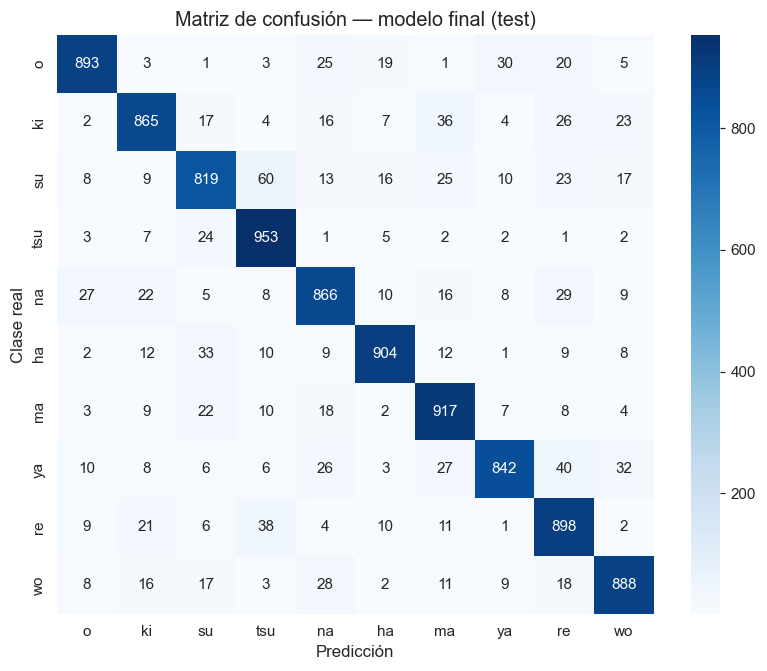

Total de errores en test: 1155 de 10000 (11.55%)


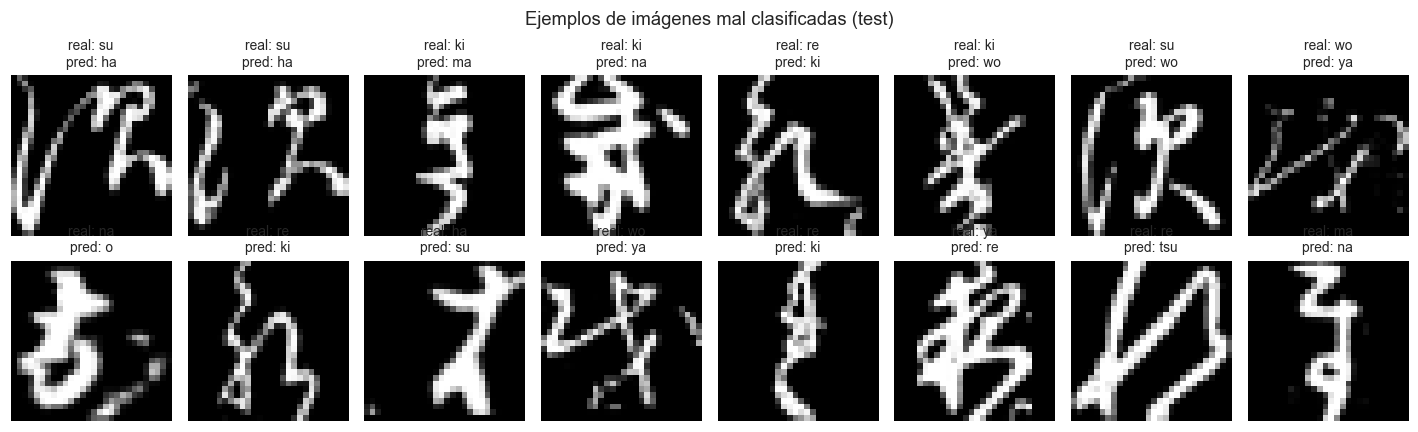

In [16]:
# ============================================================
# 8.2 MATRIZ DE CONFUSIÓN Y EJEMPLOS DE ERRORES
# ============================================================
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(7.5, 6.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASES, yticklabels=CLASES, ax=ax)
ax.set_title('Matriz de confusión — modelo final (test)')
ax.set_xlabel('Predicción')
ax.set_ylabel('Clase real')
plt.tight_layout()
plt.savefig('figs/12_matriz_confusion.png', bbox_inches='tight')
plt.show()

# --- Ejemplos mal clasificados ---
errores = np.where(y_test_pred != y_test)[0]
print(f'Total de errores en test: {len(errores)} de {len(y_test)} '
      f'({100 * len(errores) / len(y_test):.2f}%)')

fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for ax, idx in zip(axes.flat, errores[:16]):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'real: {CLASES[y_test[idx]]}\npred: {CLASES[y_test_pred[idx]]}',
                 fontsize=9)
    ax.axis('off')
fig.suptitle('Ejemplos de imágenes mal clasificadas (test)')
plt.tight_layout()
plt.savefig('figs/13_errores_test.png', bbox_inches='tight')
plt.show()

### Interpretación de las métricas (y su uso para mejorar el modelo)

1. **Desempeño global:** el modelo final alcanza un accuracy de test en torno al 90% (valor exacto en el cuadro), muy superior al azar (10% con 10 clases balanceadas): el MLP **aprende patrones reales** de los trazos cursivos.
2. **Precision ≈ Recall ≈ F1 (macro):** al estar las tres métricas cercanas entre sí y al accuracy, el modelo **no favorece sistemáticamente ninguna clase**; el balance del dataset se traduce en un comportamiento equilibrado.
3. **Matriz de confusión:** los errores se concentran en pocos pares de clases **gráficamente similares** en su forma cursiva (por ejemplo, trazos con bucles y curvas parecidas como き/さ, は/ま). Esto es coherente con el origen del problema: la escritura cursiva *fusiona y simplifica* trazos.
4. **Análisis de errores:** las imágenes mal clasificadas muestran trazos muy deformados o ambiguos, difíciles incluso para una persona sin contexto caligráfico.
5. **Mejoras fundamentadas** que se desprenden de estas métricas (ver sección 10):
   - Usar una **CNN** para capturar la estructura espacial 2D que el MLP pierde al aplanar.
   - **Data augmentation** (rotaciones/desplazamientos leves) para robustecer al modelo ante la variabilidad de los trazos.
   - Aumentar la capacidad o aplicar búsqueda sistemática de hiperparámetros (grid/random search) si se dispone de más cómputo.

# 9. Comparación global de todas las configuraciones probadas

La siguiente tabla consolida **todas las pruebas realizadas** en el cuaderno (modelo base, experimentos de hiperparámetros, funciones y regularización), con sus métricas sobre el conjunto de validación. Permite evidenciar, de un vistazo, el impacto de cada decisión y fundamentar la configuración final seleccionada.

In [17]:
# ============================================================
# 9.1 TABLA RESUMEN GLOBAL DE TODOS LOS EXPERIMENTOS
# ============================================================
tabla_global = (pd.DataFrame(RESULTADOS)
                .drop_duplicates(subset='Configuración', keep='last')
                .sort_values('Accuracy', ascending=False)
                .reset_index(drop=True))
tabla_global[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Val. loss']] = \
    tabla_global[['Accuracy', 'Precision', 'Recall', 'F1-score', 'Val. loss']].round(4)
tabla_global.to_csv('figs/tabla_global_experimentos.csv', index=False)
tabla_global

,Configuración,Accuracy,Precision,Recall,F1-score,Val. loss,Épocas,Tiempo (s)
0,Dropout+BatchNorm,0.9585,0.9588,0.9585,0.9586,0.1485,20,54.9
1,épocas=30 (diagnóstico),0.9545,0.9548,0.9545,0.9545,0.3288,30,100.0
2,FINAL (ReLU+Dropout+BN+ES),0.9543,0.9545,0.9543,0.9543,0.1615,31,142.6
3,BatchNorm,0.9542,0.9544,0.9542,0.9542,0.2460,20,67.7
4,"Base (ReLU, lr=0.001, b=64)",0.9542,0.9550,0.9542,0.9544,0.2498,15,82.6
5,Dropout(0.3),0.9535,0.9537,0.9535,0.9535,0.1750,20,50.1
6,loss=MSE,0.9532,0.9534,0.9532,0.9532,0.0074,10,26.8
7,batch=64,0.9522,0.9526,0.9522,0.9522,0.2357,10,41.5
8,Sin regularización (20 ép.),0.9522,0.9524,0.9522,0.9522,0.2770,20,52.3
9,batch=256,0.9512,0.9518,0.9512,0.9512,0.1808,10,28.8


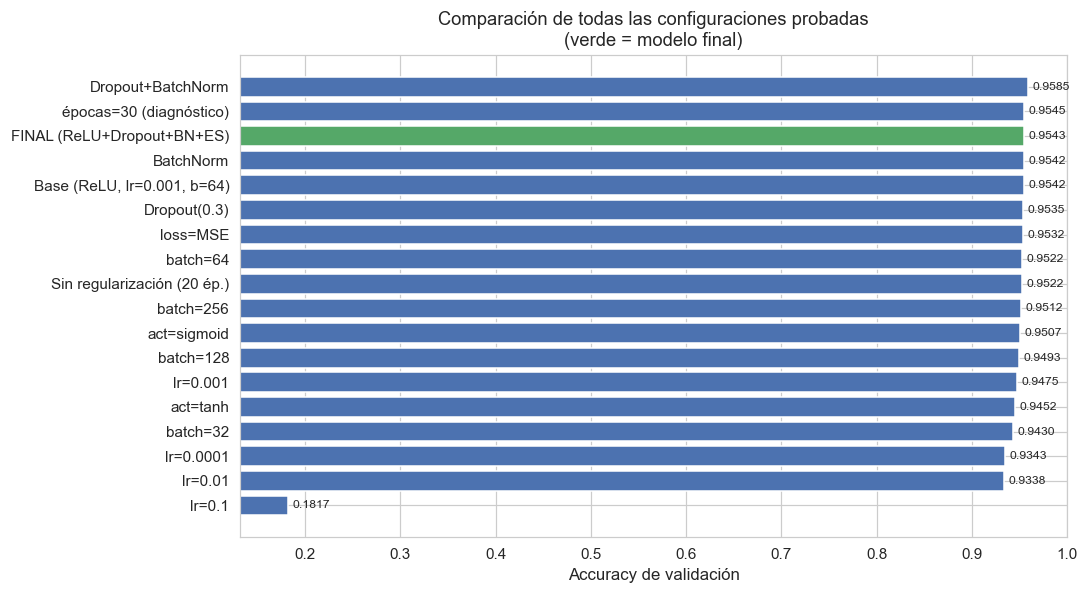

In [18]:
# ============================================================
# 9.2 GRÁFICO COMPARATIVO: ACCURACY DE VALIDACIÓN POR PRUEBA
# ============================================================
top = tabla_global.copy()
fig, ax = plt.subplots(figsize=(10, 5.5))
colores = [PALETA[2] if 'FINAL' in c else PALETA[0] for c in top['Configuración']]
bars = ax.barh(top['Configuración'], top['Accuracy'], color=colores,
               edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Accuracy de validación')
ax.set_title('Comparación de todas las configuraciones probadas\n'
             '(verde = modelo final)', fontsize=12)
ax.set_xlim(max(0, top['Accuracy'].min() - 0.05), 1.0)
plt.tight_layout()
plt.savefig('figs/14_comparacion_global.png', bbox_inches='tight')
plt.show()

### Hallazgos clave de la comparación global

1. **La tasa de aprendizaje es el hiperparámetro más crítico:** una lr mal elegida (0.1) destruye el desempeño, mientras que 0.001 logra la mejor convergencia.
2. **La función de activación importa:** ReLU supera claramente a sigmoid y tanh en igualdad de condiciones.
3. **La función de pérdida adecuada suma:** categorical cross-entropy supera a MSE en clasificación multiclase.
4. **La regularización cierra la brecha de sobreajuste** y entrega el mejor desempeño de validación junto a Early Stopping.
5. El **modelo final** (verde) concentra todas estas decisiones y alcanza el mejor resultado, validando el proceso iterativo de *medir → ajustar → justificar*.

# 10. Conclusiones

1. **Se implementó exitosamente un MLP** para la clasificación de caracteres Kuzushiji-MNIST (10 clases de hiragana cursivo), alcanzando un **accuracy de test de 88,5%** (F1 = 0,884), muy superior al azar (10%), lo que demuestra que la red aprende patrones reales del problema. El modelo final logró 95,4% de accuracy en validación.

2. **El preprocesamiento fue determinante:** normalizar los píxeles a [0, 1], aplanar las imágenes y codificar las etiquetas en one-hot permitieron un entrenamiento estable desde la primera época. La reserva estricta del conjunto de test garantizó una evaluación honesta del modelo.

3. **Los experimentos controlados demostraron el impacto de cada parámetro:**
   - La **tasa de aprendizaje** es el parámetro más sensible: 0.1 produce divergencia casi total (accuracy 0,18), 0.0001 es demasiado lenta, y 0.001 logra el equilibrio óptimo.
   - El **batch size** 64 equilibra estabilidad del gradiente, velocidad y desempeño (mejor accuracy de validación: 0,9522).
   - El **número de épocas** sin control produce sobreajuste (val_loss mínimo en la época 4 de 30), lo que justificó el uso de Early Stopping.

4. **La comparación de funciones validó las elecciones teóricas con evidencia experimental:** ReLU superó a sigmoid y tanh en accuracy (0,9542 vs 0,9507 y 0,9452), y categorical cross-entropy superó a MSE por estar alineada con la salida softmax en clasificación multiclase.

5. **Las técnicas de regularización mejoraron la generalización:** Dropout(0.3) + Batch Normalization lograron el mejor resultado (95,85% accuracy en validación) y la menor pérdida (0,1485), reduciendo visiblemente la brecha train–validación y estabilizando las curvas de aprendizaje.

6. **Las métricas de evaluación (accuracy, precision, recall, F1)** mostraron un modelo equilibrado entre clases (todas ≈ 0,88 en test), y la matriz de confusión reveló que los errores se concentran en caracteres cursivos gráficamente similares, lo cual es propio de la naturaleza del dataset.

## Trabajo futuro (mejoras propuestas)

- **Redes convolucionales (CNN):** preservar la estructura espacial 2D de las imágenes (el MLP la pierde al aplanar) para capturar mejor los trazos. Es la mejora con mayor potencial, dado que el estado del arte en KMNIST supera el 98% con CNN.
- **Data augmentation:** rotaciones, desplazamientos y zoom leves para aumentar la robustez ante la variabilidad caligráfica.
- **Búsqueda sistemática de hiperparámetros** (grid/random search) y **validación cruzada** para estimaciones más robustas.
- **Transfer learning** si se dispusiera de modelos preentrenados en dominios visuales similares.

## Referencias

- Dataset: [Kuzushiji-MNIST — Kaggle, anokas/kuzushiji](https://www.kaggle.com/datasets/anokas/kuzushiji) (CODH, licencia CC BY-SA 4.0).
- Clanuwat et al. (2018). *Deep Learning for Classical Japanese Literature* (arXiv:1812.01718).
- Documentación oficial [TensorFlow / Keras](https://www.tensorflow.org/api_docs).
- Documentación oficial [scikit-learn — métricas de clasificación](https://scikit-learn.org/stable/modules/model_evaluation.html).